# Group 8: Machine Learning Group Project

**Members:** Amaru Izarra-Jacome, Nikhilkumar Patel, Silvio Silva Junior, Hugo Velasco, Aten Cheung, Robert Allan Bolista

**Dataset:** NASA NEO Dataset https://www.kaggle.com/datasets/ivansher/nasa-nearest-earth-objects-1910-2024?select=nearest-earth-objects%281910-2024%29.csv)

**Goal:** Near-Earth Objects (NEOs) are asteroids and comets whose orbits bring them into proximity with Earth's path around the Sun. While the vast majority pose no immediate threat, a small fraction are classified as Potentially Hazardous Asteroids (PHAs). This is a designation with meaningful implications for planetary defence planning, emergency preparedness, and the long-term safety of human civilization.
The central objective of this project is to build a machine learning classification system that can identify which observable asteroid properties are most strongly associated with a hazardous orbit designation.


In [ ]:
# Install if needed
!pip install pandas matplotlib seaborn scikit-learn xgboost lightgbm

In [ ]:
# imports
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_curve, roc_auc_score,auc
from sklearn.svm import SVC, LinearSVC
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)

**Data Cleaning**

group member: Amaru Izarra-Jacome

In [ ]:
# loading the data
# Download latest version
path = kagglehub.dataset_download("ivansher/nasa-nearest-earth-objects-1910-2024")

print("Path to dataset files:", path)

files = os.listdir(path)
print(files)
df = pd.read_csv(os.path.join(path, files[0]))

print(f'Shape: {df.shape}')
df.head()

Using Colab cache for faster access to the 'nasa-nearest-earth-objects-1910-2024' dataset.
Path to dataset files: /kaggle/input/nasa-nearest-earth-objects-1910-2024
['nearest-earth-objects(1910-2024).csv']
Shape: (338199, 9)


,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.14,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.50,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.45,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.63,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.70,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False


In [ ]:
# data quality checks
print('--- Data types ---')
print(df.dtypes)
print('\n--- Missing values (percent) ---')
print(df.isnull().sum()/len(df)*100)
print('\n--- Basic stats ---')
df.describe()

--- Data types ---
neo_id                      int64
name                       object
absolute_magnitude        float64
estimated_diameter_min    float64
estimated_diameter_max    float64
orbiting_body              object
relative_velocity         float64
miss_distance             float64
is_hazardous                 bool
dtype: object

--- Missing values (percent) ---
neo_id                    0.000000
name                      0.000000
absolute_magnitude        0.008279
estimated_diameter_min    0.008279
estimated_diameter_max    0.008279
orbiting_body             0.000000
relative_velocity         0.000000
miss_distance             0.000000
is_hazardous              0.000000
dtype: float64

--- Basic stats ---


,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


Since missing data represent less than 0.01% of the data we will just drop those rows instead of inputing.

In [ ]:
df_dropped = df.dropna()

# check it worked
print('\n--- Missing values (percent) ---')
print(df.isnull().sum()/len(df)*100)


--- Missing values (percent) ---
neo_id                    0.000000
name                      0.000000
absolute_magnitude        0.008279
estimated_diameter_min    0.008279
estimated_diameter_max    0.008279
orbiting_body             0.000000
relative_velocity         0.000000
miss_distance             0.000000
is_hazardous              0.000000
dtype: float64


No one-hot encoding needed since we will just drop the categorical columns, no real information in the 'name' or 'orbiting body' (always Earth). Target column will be converted to int for training, were (hazardous = 1, not hazardous = 0)

In [ ]:
# Drop zero-value and identifier columns
df_cleaned = df_dropped.drop(columns=['neo_id', 'name', 'orbiting_body'])

# Convert target to int
df_cleaned['is_hazardous'] = df_cleaned['is_hazardous'].astype(int)

print(df_cleaned.dtypes)
print(f'\nFinal shape: {df_cleaned.shape}')

absolute_magnitude        float64
estimated_diameter_min    float64
estimated_diameter_max    float64
relative_velocity         float64
miss_distance             float64
is_hazardous                int64
dtype: object

Final shape: (338171, 6)


**Data Analysis**

Group member: Amaru Izarra-Jacome

is_hazardous
0    295009
1     43162
Name: count, dtype: int64

Hazardous: 12.8%  |  Non-hazardous: 87.2%


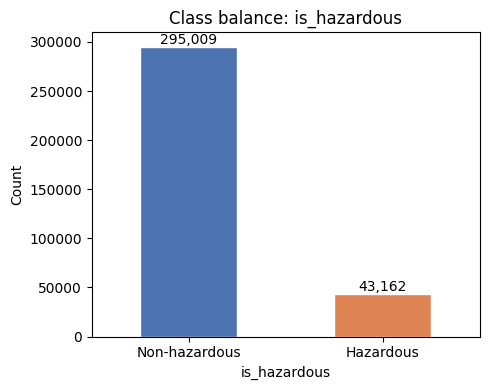

In [ ]:
# Class Balance
counts = df_cleaned['is_hazardous'].value_counts()
pct = df_cleaned['is_hazardous'].value_counts(normalize=True) * 100

print(counts)
print(f'\nHazardous: {pct[1]:.1f}%  |  Non-hazardous: {pct[0]:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_title('Class balance: is_hazardous')
ax.set_xticklabels(['Non-hazardous', 'Hazardous'], rotation=0)
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


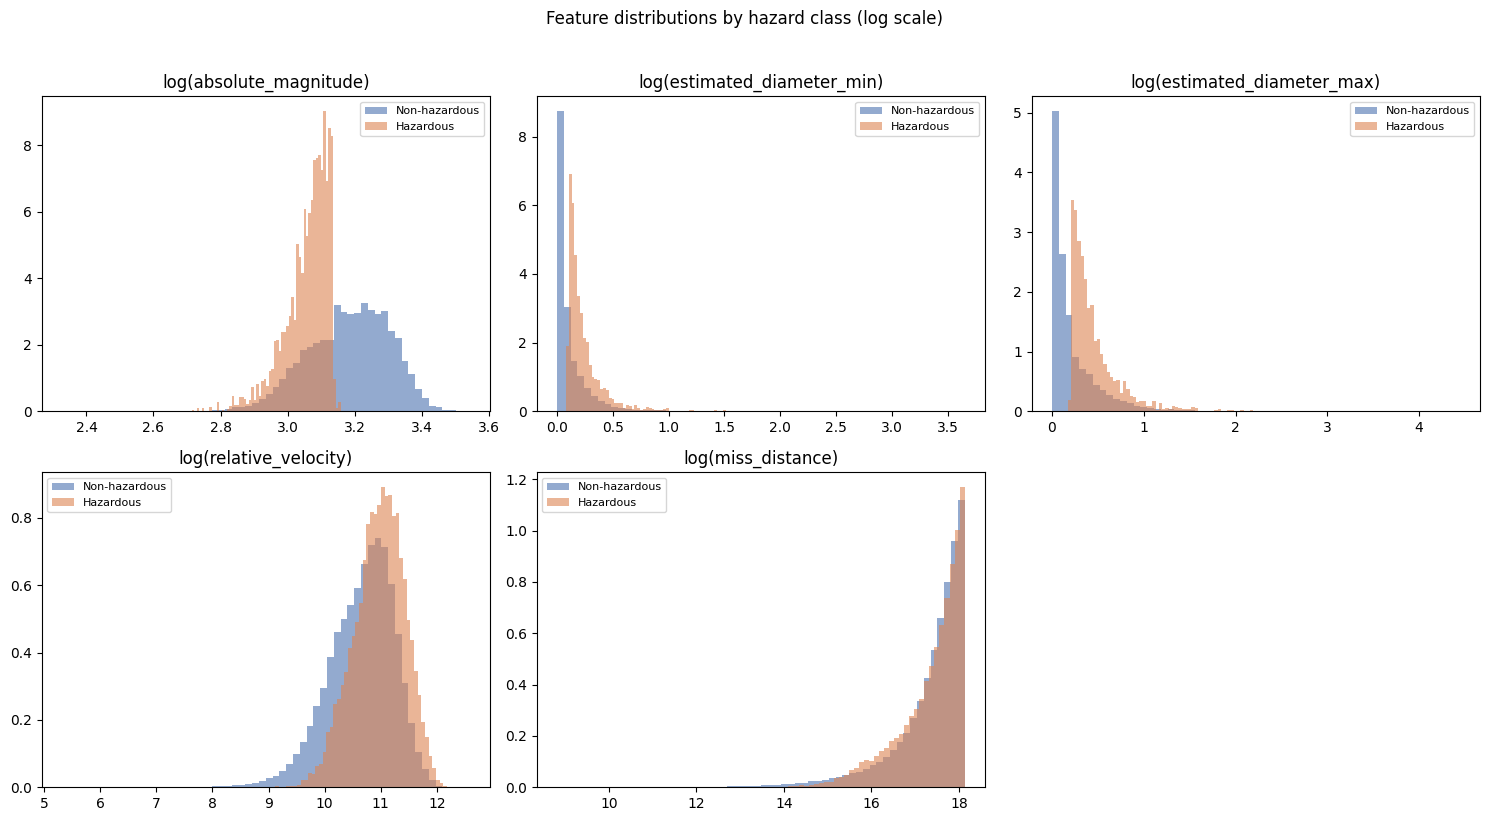

In [ ]:
# feature distribution by class
features = ['absolute_magnitude', 'estimated_diameter_min',
            'estimated_diameter_max', 'relative_velocity', 'miss_distance']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    for label, color in [(False, '#4C72B0'), (True, '#DD8452')]:
        subset = df_cleaned[df_cleaned['is_hazardous'] == label][col].dropna()
        subset = np.log1p(subset)
        ax.hist(subset, bins=60, alpha=0.6, color=color,
                label='Hazardous' if label else 'Non-hazardous', density=True)
    ax.set_title(f'log({col})')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Feature distributions by hazard class (log scale)', y=1.02)
plt.tight_layout()
plt.show()

From these plots we can see that miss_distance has a pretty weak signal in comparison to another feature such as absolute_magnitude. This will be taken into account in the feature engineering. Where features that have relatively stronger signals will be used to engineering more strong signal features.

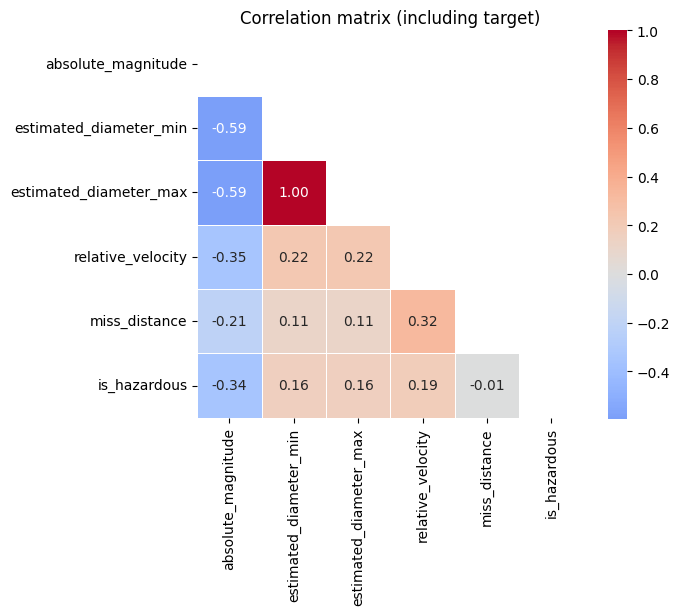


Correlation with is_hazardous:
absolute_magnitude       -0.343996
relative_velocity         0.187021
estimated_diameter_min    0.164841
estimated_diameter_max    0.164841
miss_distance            -0.006540
Name: is_hazardous, dtype: float64


In [ ]:
# Correlation Matrix

# Encode target as 0/1 for correlation
df_numeric = df[features].copy()
df_numeric['is_hazardous'] = df['is_hazardous'].astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
corr = df_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation matrix (including target)')
plt.tight_layout()
plt.show()


print('\nCorrelation with is_hazardous:')
print(corr['is_hazardous'].drop('is_hazardous').sort_values(key=abs, ascending=False))

From this correlation matrix we can see two main things. absolute_magnitude and relative_velocity have the strongest correlation with the target, while miss_distance has the weakest. This lines up with what we observed in the feature distributions. The other important insight from this matrix is that estimated_diameter_max and estimated_diameter_min have a perfect correlation of 1.0, they are completely redundant, meaning that knowing one tells you the other with 100% certainty. Therefore, rather than keeping both, we replace them with a single estimated_diameter_mean feature that consolidates both into one unified measure.

In [ ]:
df_cleaned['estimated_diameter_mean'] = (
    df_cleaned['estimated_diameter_min'] + df_cleaned['estimated_diameter_max']
) / 2

df_cleaned1 = df_cleaned.drop(columns=['estimated_diameter_min', 'estimated_diameter_max'])
features = ['absolute_magnitude', 'estimated_diameter_mean', 'relative_velocity', 'miss_distance']

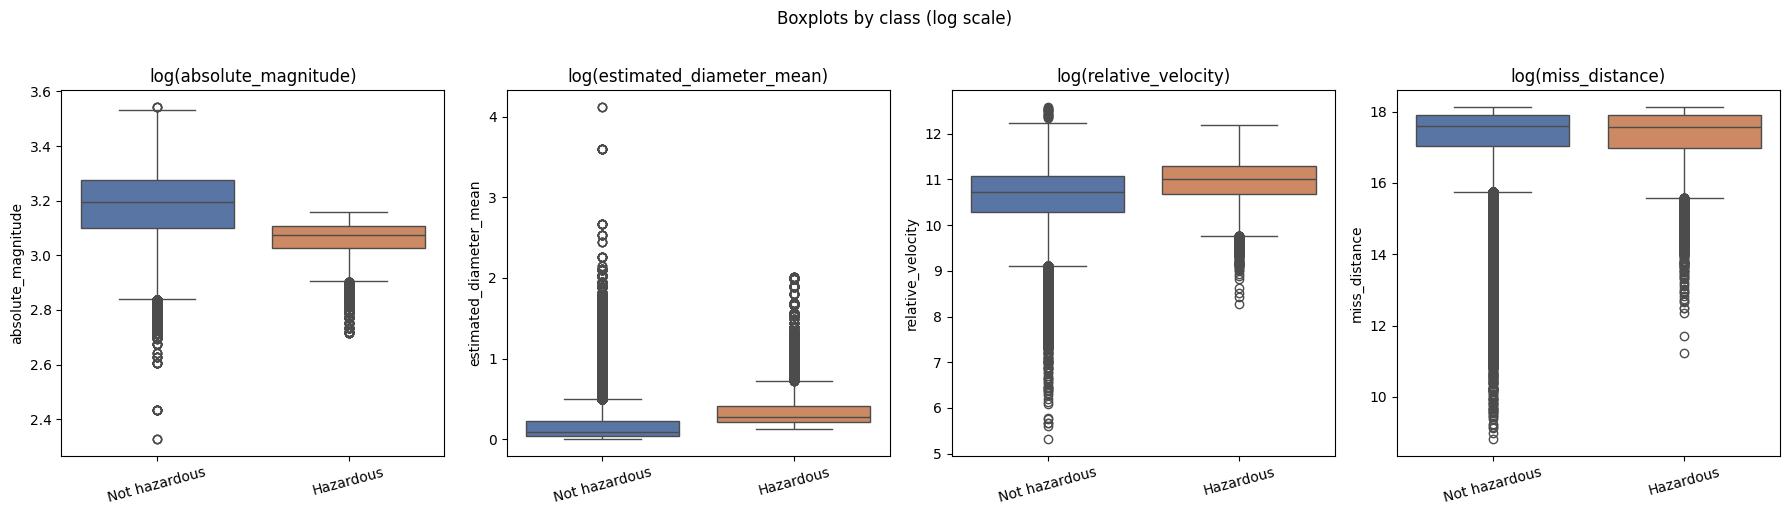

In [ ]:
# box-plots
fig, axes = plt.subplots(1, len(features), figsize=(18, 5))

for ax, col in zip(axes, features):
    plot_df = df_cleaned1[['is_hazardous', col]].copy()
    plot_df[col] = np.log1p(plot_df[col])
    plot_df['Class'] = plot_df['is_hazardous'].map({1: 'Hazardous', 0: 'Not hazardous'})
    sns.boxplot(data=plot_df, x='Class', y=col, ax=ax,
                hue='Class', legend=False,
                palette={'Hazardous': '#DD8452', 'Not hazardous': '#4C72B0'})
    ax.set_title(f'log({col})')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Boxplots by class (log scale)', y=1.02)
plt.tight_layout()
plt.show()

The boxplots reinforce what we saw in the correlation matrix. absolute_magnitude shows the clearest separation between classes; the median for hazardous objects sits noticeably lower than for non-hazardous ones, which makes physical sense since a lower absolute magnitude indicates a brighter and therefore larger asteroid. relative_velocity and estimated_diameter_mean also show a modest shift in medians between classes, suggesting some predictive signal. miss_distance on the other hand shows almost identical distributions for both classes, consistent with its near-zero correlation of with the target. This confirms that how close an asteroid gets on a given observation is not a reliable indicator of whether it is classified as hazardous.

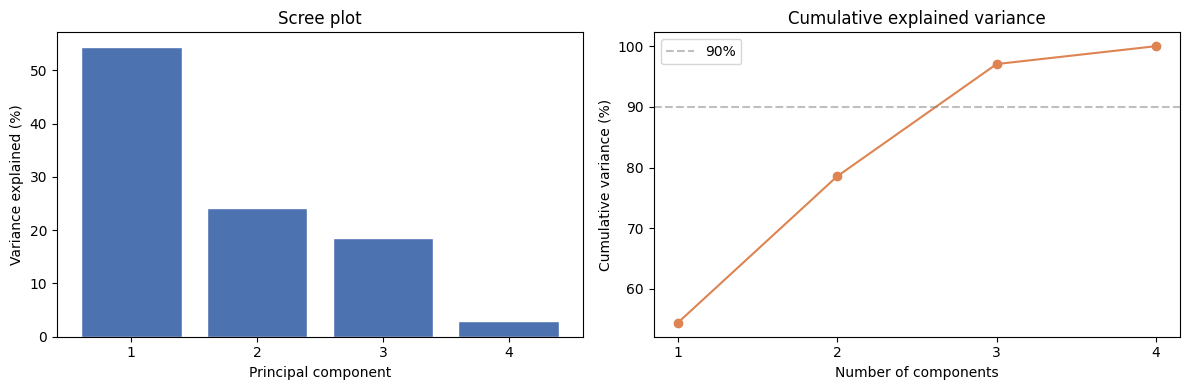

Variance explained per component:
  PC1: 54.4%
  PC2: 24.2%
  PC3: 18.5%
  PC4: 2.9%


In [ ]:
# Principal component analysis

# Prepare features
X = df_cleaned1[features].dropna().copy()
y = df_cleaned1.loc[X.index, 'is_hazardous'].astype(int)

# Log-transform skewed features before scaling
for col in features:
    X[col] = np.log1p(X[col])

# Standardize (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Full PCA to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(features)+1), pca_full.explained_variance_ratio_ * 100,
            color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, len(features)+1))

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(features)+1), cumvar, 'o-', color='#DD8452')
axes[1].axhline(90, ls='--', color='gray', alpha=0.5, label='90%')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xticks(range(1, len(features)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

print('Variance explained per component:')
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.1f}%')

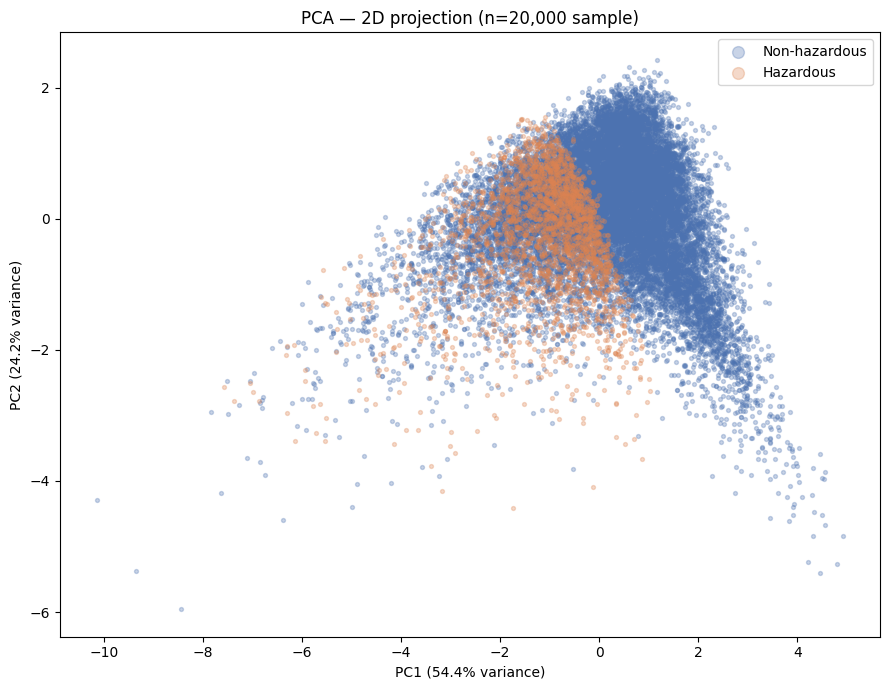

In [ ]:
# Project to 2D and plot
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# Subsample for legibility
sample_size = 20000
idx = np.random.choice(len(X_2d), size=sample_size, replace=False)
X_plot = X_2d[idx]
y_plot = y.values[idx]

fig, ax = plt.subplots(figsize=(9, 7))
colors = {0: '#4C72B0', 1: '#DD8452'}
labels = {0: 'Non-hazardous', 1: 'Hazardous'}

for cls in [0, 1]:
    mask = y_plot == cls
    ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
               c=colors[cls], label=labels[cls],
               alpha=0.3, s=8, rasterized=True)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'PCA — 2D projection (n={sample_size:,} sample)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

The PCA projection reduces our feature space to two dimensions, together capturing 78.6% of the total variance (PC1: 54.4%, PC2: 24.2%). The plot reveals a partial but meaningful separation between hazardous and non-hazardous objects. Hazardous asteroids (orange) concentrate in the central region of the plot, while non-hazardous objects (blue) dominate the right side and the extremes. Crucially, the two classes are not cleanly separable as there is significant overlap in the middle, which is consistent with our earlier finding that the key classification features used by NASA (MOID and absolute magnitude thresholds) are not directly present in this dataset.


This result tells us two things. First, there is genuine learnable signal in our features, a model that predicts randomly would show no directional structure at all. Second, we should not expect perfect classification accuracy, and any model reporting near 100% accuracy on this dataset should be treated with suspicion. Our goal is therefore not to perfectly replicate NASA's classification rule, but to identify which observable asteroid properties are most predictive of a hazardous orbit, framing our model as a triage tool rather than a definitive classifier.

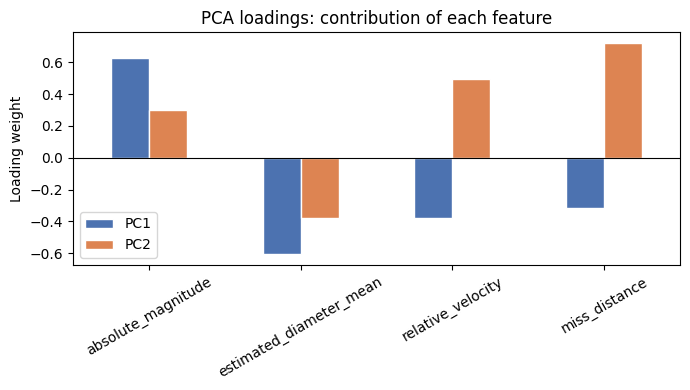

                           PC1    PC2
absolute_magnitude       0.624  0.298
estimated_diameter_mean -0.607 -0.380
relative_velocity       -0.377  0.496
miss_distance           -0.317  0.722


In [ ]:
# PCA loadings to determine which original features drive each component
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=features,
    columns=['PC1', 'PC2']
)

fig, ax = plt.subplots(figsize=(7, 4))
loadings.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_title('PCA loadings: contribution of each feature')
ax.set_ylabel('Loading weight')
ax.axhline(0, color='black', linewidth=0.8)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(loadings.round(3))

The loadings tell us what PC1 represents: mostly size (diameter up, magnitude down). PC2 is mostly miss_distance + velocity. So the dataset essentially reduces to two physical dimensions; size and orbital dynamics.

In [ ]:
# Final cleaned data set
df_final = df_cleaned1.copy()

**Feature Engineering**

Group member: Nik Patel

In [ ]:
# add the feature engineering code here
# square function
def square(n):
   return n ** 2

In [ ]:
df_final.head()

,absolute_magnitude,relative_velocity,miss_distance,is_hazardous,estimated_diameter_mean
0,19.14,71745.401048,5.814362e+07,0,0.639061
1,18.50,109949.757148,5.580105e+07,1,0.858109
2,21.45,24865.506798,6.720689e+07,0,0.220568
3,20.63,78890.076805,3.039644e+07,0,0.321768
4,22.70,56036.519484,6.311863e+07,0,0.124035


In [ ]:
# Feature engineering to add 3 features , Kinetic energy , size of distance ratio , magnitude velocity
df_final['kinetic_energy'] = square(df_final['estimated_diameter_mean']) * square(df_final['relative_velocity'])
df_final['size_to_distance_ratio'] = df_final['estimated_diameter_mean'] / df_final['miss_distance']
df_final['magnitude_velocity'] = df_final['absolute_magnitude'] * df_final['relative_velocity']

In [ ]:
df_final.head()

,absolute_magnitude,relative_velocity,miss_distance,is_hazardous,estimated_diameter_mean,kinetic_energy,size_to_distance_ratio,magnitude_velocity
0,19.14,71745.401048,5.814362e+07,0,0.639061,2.102197e+09,1.099108e-08,1.373207e+06
1,18.50,109949.757148,5.580105e+07,1,0.858109,8.901717e+09,1.537801e-08,2.034071e+06
2,21.45,24865.506798,6.720689e+07,0,0.220568,3.008014e+07,3.281926e-09,5.333651e+05
3,20.63,78890.076805,3.039644e+07,0,0.321768,6.443621e+08,1.058571e-08,1.627502e+06
4,22.70,56036.519484,6.311863e+07,0,0.124035,4.830894e+07,1.965102e-09,1.272029e+06


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338171 entries, 0 to 338198
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   absolute_magnitude       338171 non-null  float64
 1   relative_velocity        338171 non-null  float64
 2   miss_distance            338171 non-null  float64
 3   is_hazardous             338171 non-null  int64  
 4   estimated_diameter_mean  338171 non-null  float64
 5   kinetic_energy           338171 non-null  float64
 6   size_to_distance_ratio   338171 non-null  float64
 7   magnitude_velocity       338171 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 31.3 MB


In [ ]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
absolute_magnitude,338171.0,2.293252e+01,2.911216e+00,9.250000e+00,2.074000e+01,2.280000e+01,2.510000e+01,3.358000e+01
relative_velocity,338171.0,5.106002e+04,2.639992e+04,2.033464e+02,3.071063e+04,4.755705e+04,6.667322e+04,2.917811e+05
miss_distance,338171.0,4.153547e+07,2.077411e+07,6.745533e+03,2.494495e+07,4.332724e+07,5.933961e+07,7.479865e+07
is_hazardous,338171.0,1.276337e-01,3.336819e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
estimated_diameter_mean,338171.0,2.553453e-01,5.078768e-01,8.270706e-04,4.107169e-02,1.184521e-01,3.058740e-01,6.074949e+01
kinetic_energy,338171.0,1.594977e+09,4.537525e+10,2.477923e+01,2.135077e+06,2.484517e+07,2.736602e+08,1.793204e+13
size_to_distance_ratio,338171.0,8.647227e-09,2.722531e-08,1.453274e-11,1.307108e-09,3.755470e-09,8.739609e-09,5.658855e-06
magnitude_velocity,338171.0,1.144376e+06,5.537686e+05,4.516324e+03,7.225437e+05,1.073836e+06,1.491728e+06,5.058058e+06


In [ ]:
# Save unscaled copy before StandardScaler overwrites the values
df_final_unscaled = df_final.copy()

#Feature Scaling
numerical_features = ['absolute_magnitude', 'estimated_diameter_mean','relative_velocity', 'kinetic_energy' , 'size_to_distance_ratio' ,
                        'magnitude_velocity']

scaler = StandardScaler()
df_final[numerical_features] = scaler.fit_transform(df_final[numerical_features])

In [ ]:
df_final

,absolute_magnitude,relative_velocity,miss_distance,is_hazardous,estimated_diameter_mean,kinetic_energy,size_to_distance_ratio,magnitude_velocity
0,-1.302731,0.783541,5.814362e+07,0,0.755531,0.011178,0.086091,0.413225
1,-1.522570,2.230682,5.580105e+07,1,1.186833,0.161029,0.247226,1.606620
2,-0.509247,-0.992221,6.720689e+07,0,-0.068476,-0.034488,-0.197071,-1.103371
3,-0.790916,1.054174,3.039644e+07,0,0.130785,-0.020950,0.071201,0.872434
4,-0.079872,0.188505,6.311863e+07,0,-0.258549,-0.034086,-0.245438,0.230517
...,...,...,...,...,...,...,...,...
338194,1.939905,0.211629,6.406548e+07,0,-0.486486,-0.035146,-0.312876,0.857028
338195,1.977690,-1.133689,2.948883e+07,0,-0.487290,-0.035150,-0.307825,-0.971769
338196,-0.348145,-1.485915,5.346078e+07,0,-0.152838,-0.035053,-0.195512,-1.598196
338197,0.327862,0.194636,5.184742e+06,0,-0.361392,-0.034792,0.191061,0.357613


In [ ]:
#feature Selection and Normalization
selected_features = ['absolute_magnitude', 'estimated_diameter_mean',
                     'relative_velocity', 'kinetic_energy' ,'size_to_distance_ratio' , 'magnitude_velocity']
X = df_final[selected_features]
y = df_final['is_hazardous']

In [ ]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

**Dummy Classifier**

Group member: Silvio

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
# A dummy model gives us the minimum bar every real model must beat.

from sklearn.dummy import DummyClassifier

# due to the class imbalance let's use "most_frequent" so it predicts the majority class
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

# Predict
y_pred_dummy = dummy.predict(X_test)

# Evaluate
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
classification_rep_dummy = classification_report(y_test, y_pred_dummy, zero_division=0)
conf_matrix_dummy = confusion_matrix(y_test, y_pred_dummy)

print(f"Baseline Accuracy (most_frequent): {accuracy_dummy:.4f}")
print("Classification Report:")
print(classification_rep_dummy)
print("Confusion Matrix:")
print(conf_matrix_dummy)

Baseline Accuracy (most_frequent): 0.8736
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     59088
           1       0.00      0.00      0.00      8547

    accuracy                           0.87     67635
   macro avg       0.44      0.50      0.47     67635
weighted avg       0.76      0.87      0.81     67635

Confusion Matrix:
[[59088     0]
 [ 8547     0]]


**Logistic Regression**

Group member: Nik Patel

In [ ]:
log_reg_mdl = LogisticRegression(max_iter=1000, random_state=42)
log_reg_mdl.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_log_reg = log_reg_mdl.predict(X_test)

In [ ]:
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
classification_rep_log_reg = classification_report(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

In [ ]:
print(f"Accuracy of logistic regression: {accuracy_log_reg}")
print("Classification Report:")
print(classification_rep_log_reg)
print("Confusion Matrix:")
print(conf_matrix_log_reg)

Accuracy of logistic regression: 0.8736157314999631
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     59088
           1       0.49      0.00      0.01      8547

    accuracy                           0.87     67635
   macro avg       0.68      0.50      0.47     67635
weighted avg       0.83      0.87      0.82     67635

Confusion Matrix:
[[59060    28]
 [ 8520    27]]


Logistic regtression model achieved high accuracy rate ; The precision and recall for the hazardous class (1) are relatively low, indicating that the model struggles to correctly identify hazardous objects.This suggests that further tuning or a different approach might be needed to improve the detection of hazardous object

**Random Forest**

Group Member: Robert

Random Forest Accuracy: 0.9110223996451542
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     59088
           1       0.71      0.50      0.59      8547

    accuracy                           0.91     67635
   macro avg       0.82      0.73      0.77     67635
weighted avg       0.90      0.91      0.90     67635

Confusion Matrix:
[[57351  1737]
 [ 4281  4266]]


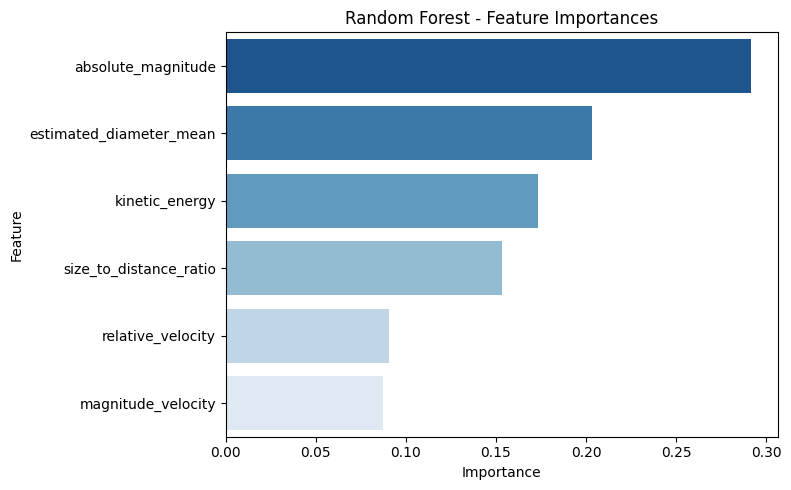

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Random Forest - Feature Importances')
plt.tight_layout()
plt.show()

# print("--- Model Comparison ---")
# print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
# print(f"Random Forest Accuracy:       {accuracy_rf:.4f}")

**XGBoost Classifier**

Group Member: Silvio

In [ ]:
## Silvio
# XGBoost Classifier
# https://xgboost.readthedocs.io/en/latest/get_started.html
# (same as scikit learn but much faster - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)
from xgboost import XGBClassifier

# Train
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
classification_rep_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"GradientBoosting (XGBoost): {accuracy_xgb:.4f}")
print("Classification Report:")
print(classification_rep_xgb)
print("Confusion Matrix:")
print(conf_matrix_xgb)

GradientBoosting (XGBoost): 0.8929
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     59088
           1       0.70      0.27      0.39      8547

    accuracy                           0.89     67635
   macro avg       0.80      0.63      0.66     67635
weighted avg       0.88      0.89      0.87     67635

Confusion Matrix:
[[58113   975]
 [ 6267  2280]]


**AdaBoost Classifier**

Group Member: Silvio

In [ ]:
## Silvio
## AdaBoost Classifier
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Train
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada.fit(X_train, y_train)

# Predict
y_pred_ada = ada.predict(X_test)

# Evaluate
accuracy_ada = accuracy_score(y_test, y_pred_ada)
classification_rep_ada = classification_report(y_test, y_pred_ada, zero_division=0)
conf_matrix_ada = confusion_matrix(y_test, y_pred_ada)

print(f"Accuracy of AdaBoost: {accuracy_ada:.4f}")
print("Classification Report:")
print(classification_rep_ada)
print("Confusion Matrix:")
print(conf_matrix_ada)


Accuracy of AdaBoost: 0.8736
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     59088
           1       0.00      0.00      0.00      8547

    accuracy                           0.87     67635
   macro avg       0.44      0.50      0.47     67635
weighted avg       0.76      0.87      0.81     67635

Confusion Matrix:
[[59088     0]
 [ 8547     0]]


## Support Vector Machine (SVM)

Group member: Hugo Velasco

SVM finds the optimal hyperplane that maximizes the margin between classes.
We test **both Linear and RBF kernels**, tuned with GridSearchCV.

In [ ]:
# LINEAR SVM
linear_svm = LinearSVC(C=100, class_weight='balanced', max_iter=3000, random_state=42)
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
accuracy_svm_linear = accuracy_score(y_test, y_pred_linear)

print("LINEAR SVM (C=100)")
print(f"Accuracy: {accuracy_svm_linear:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear, target_names=['Not Hazardous', 'Hazardous']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

LINEAR SVM (C=100)
Accuracy: 0.7219

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       0.98      0.69      0.81     59088
    Hazardous       0.30      0.93      0.46      8547

     accuracy                           0.72     67635
    macro avg       0.64      0.81      0.64     67635
 weighted avg       0.90      0.72      0.77     67635

Confusion Matrix:
[[40905 18183]
 [  629  7918]]



Linear SVM achieved **72% accuracy** with a recall of **0.93 on the hazardous class** —
meaning it catches 93% of dangerous asteroids. The tradeoff is a precision of 0.30,
which means many false alarms (non-hazardous objects flagged as dangerous).

For asteroid detection, **high recall is the right priority**: missing a real threat
is far worse than a false alarm.

Varying C (1, 10, 100) produced virtually identical results, which tells us the data
is **not linearly separable** — the model hits a performance ceiling regardless of
margin strictness. The decision boundary plot confirmed this: both classes overlap
heavily in the same region of feature space.

**Next: RBF kernel SVM.** Instead of a straight hyperplane, RBF draws curved
boundaries that can wrap around non-linear class distributions. The tradeoff is
significantly higher training time (O(n²)), so we train on a 50k subsample with
the best C=100 found during our sweep.

In [ ]:
# RBF SVM: TRAIN + EVALUATE

SAMPLE_SIZE = 20000 # 20k subsample — RBF scales O(n2), full dataset is too slow.
idx_sample  = np.random.RandomState(42).choice(len(X_train), SAMPLE_SIZE, replace=False)
X_train_sub = X_train[idx_sample]
y_train_sub = y_train.values[idx_sample]

rbf_svm = SVC(kernel='rbf', C=100, gamma='scale', class_weight='balanced',  # C=100 selected from earlier sweep. gamma='scale' = 1/(n_features * X.var())
              probability=True, random_state=42)
rbf_svm.fit(X_train_sub, y_train_sub)

y_pred_rbf = rbf_svm.predict(X_test)

accuracy_svm_rbf = accuracy_score(y_test, y_pred_linear)

print("RBF SVM (C=100, 20k sample)")
print(f"Accuracy: {accuracy_svm_rbf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf, target_names=['Not Hazardous', 'Hazardous']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

RBF SVM (C=100, 20k sample)
Accuracy: 0.7219

Classification Report:
               precision    recall  f1-score   support

Not Hazardous       1.00      0.66      0.80     59088
    Hazardous       0.30      0.99      0.46      8547

     accuracy                           0.70     67635
    macro avg       0.65      0.83      0.63     67635
 weighted avg       0.91      0.70      0.75     67635

Confusion Matrix:
[[39057 20031]
 [   84  8463]]


RBF recall went up (0.99 vs 0.93) but precision dropped and accuracy dropped. The blue dots inside the pink region are the false positives (precision=0.30), and that's unavoidable given how deeply both classes overlap. You simply can't draw any boundary around the orange blob without capturing some blue dots too.

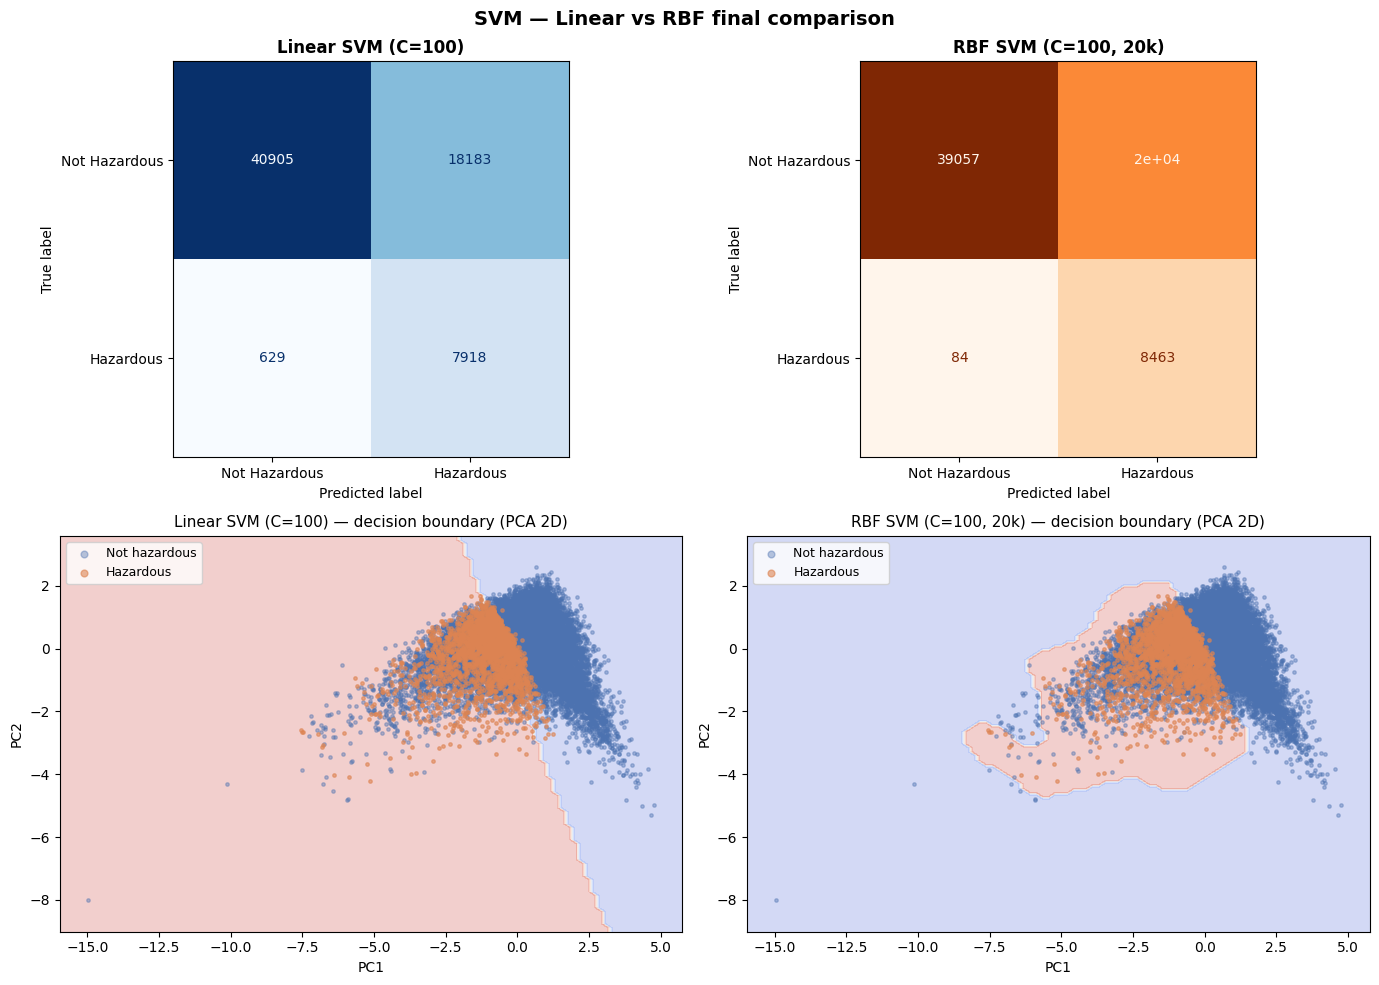

Model                      Accuracy  Precision   Recall       F1   F1-macro
---------------------------------------------------------------------------
Linear SVM (C=100)            0.722      0.303    0.926    0.457      0.635
RBF SVM (C=100 20k)           0.703      0.297    0.990    0.457      0.626


In [ ]:
import numpy as np
# FINAL COMPARISON: LINEAR vs RBF

# Define X_viz_2d and y_viz using the subsampled PCA results from before
X_viz_2d = X_plot
y_viz = y_plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrices
for ax, y_pred, title, cmap in zip(
    axes[0],
    [y_pred_linear,               y_pred_rbf],
    ['Linear SVM (C=100)',         'RBF SVM (C=100, 20k)'],
    ['Blues',                      'Oranges']
):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Hazardous', 'Hazardous'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')

# Decision boundaries
for ax, clf_viz, y_pred, title, cmap in zip(
    axes[1],
    [LinearSVC(C=100, class_weight='balanced', max_iter=3000, random_state=42),
     SVC(kernel='rbf', C=100, gamma='scale', class_weight='balanced', random_state=42)],
    [y_pred_linear, y_pred_rbf],
    ['Linear SVM (C=100) — decision boundary (PCA 2D)',
     'RBF SVM (C=100, 20k) — decision boundary (PCA 2D)'],
    ['coolwarm', 'coolwarm']
):
    clf_viz.fit(X_viz_2d, y_viz)
    DecisionBoundaryDisplay.from_estimator(
        clf_viz, X_viz_2d, ax=ax,
        alpha=0.25, cmap=cmap, response_method='predict'
    )
    ax.scatter(X_viz_2d[y_viz == 0, 0], X_viz_2d[y_viz == 0, 1],
               c='#4C72B0', s=6, alpha=0.4, label='Not hazardous')
    ax.scatter(X_viz_2d[y_viz == 1, 0], X_viz_2d[y_viz == 1, 1],
               c='#DD8452', s=6, alpha=0.6, label='Hazardous')
    ax.set_title(title, fontsize=11)
    ax.legend(markerscale=2, fontsize=9)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('SVM — Linear vs RBF final comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Metrics summary table
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'F1-macro':>10}")
print("-" * 75)
for label, y_pred in [('Linear SVM (C=100)', y_pred_linear),
                       ('RBF SVM (C=100 20k)', y_pred_rbf)]:
    print(f"{label:<25} "
          f"{accuracy_score(y_test, y_pred):>9.3f} "
          f"{precision_score(y_test, y_pred):>10.3f} "
          f"{recall_score(y_test, y_pred):>8.3f} "
          f"{f1_score(y_test, y_pred):>8.3f} "
          f"{f1_score(y_test, y_pred, average='macro'):>10.3f}")

**For asteroid danger detection, RBF SVM is the better model.** Missing a real
hazardous asteroid (false negative) is far more costly than a false alarm
(false positive). RBF misses only 84 out of 8,547 hazardous objects vs 611 for
Linear SVM.

The main limitation of RBF SVM is **scalability** — training on the full dataset
is computationally infeasible due to O(n²) complexity, so a 20k subsample was used.
For production use, `SGDClassifier` with an RBF approximation (`RBFSampler`) would
scale to the full dataset while preserving similar decision boundaries.

## Gradient Boost (LightGBM)

Group member: Aten Cheung

In [ ]:
import lightgbm as lgb

# Train LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,          # unlimited depth (leaf-wise growth)
    num_leaves=31,         # default — controls complexity
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)

# Predict
y_pred_lgb = lgb_model.predict(X_test)

# Evaluate
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
classification_rep_lgb = classification_report(y_test, y_pred_lgb)
conf_matrix_lgb = confusion_matrix(y_test, y_pred_lgb)

print(f"LightGBM Accuracy: {accuracy_lgb:.4f}")
print("\nClassification Report:")
print(classification_rep_lgb)
print("\nConfusion Matrix:")
print(conf_matrix_lgb)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.7425

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83     59088
           1       0.33      0.98      0.49      8547

    accuracy                           0.74     67635
   macro avg       0.66      0.84      0.66     67635
weighted avg       0.91      0.74      0.79     67635


Confusion Matrix:
[[41830 17258]
 [  156  8391]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


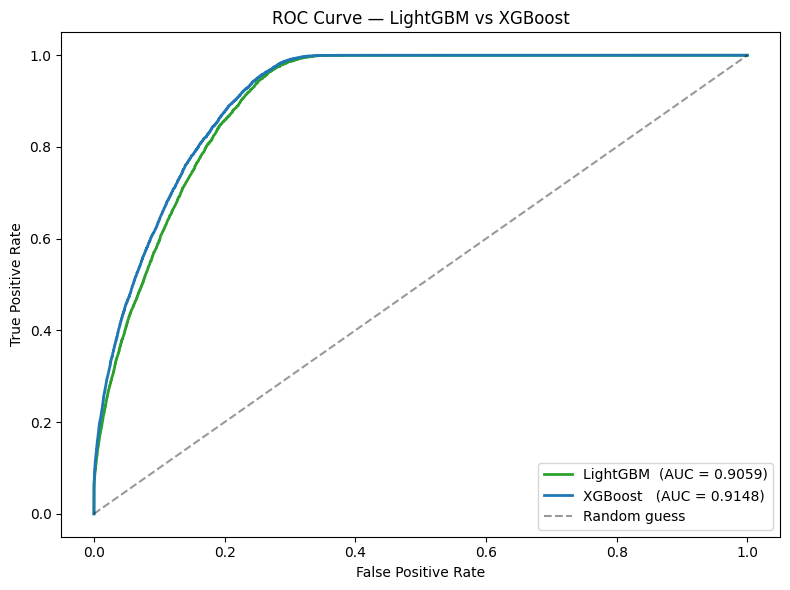

In [ ]:
# ROC Curve — LightGBM vs XGBoost
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lgb = roc_auc_score(y_test, y_prob_lgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM  (AUC = {auc_lgb:.4f})', color='#2ca02c', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost   (AUC = {auc_xgb:.4f})', color='#1f77b4', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LightGBM vs XGBoost')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

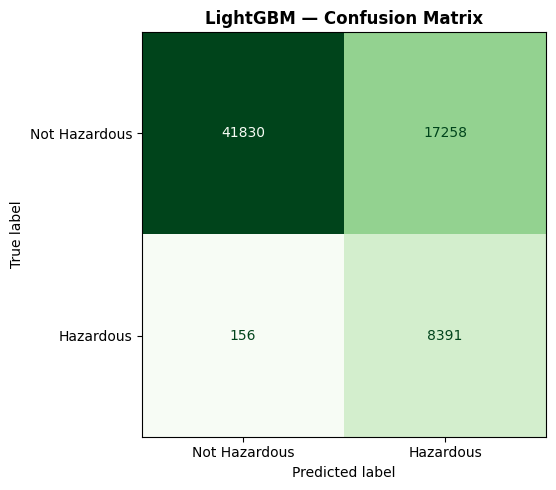

In [ ]:
# Confusion Matrix — LightGBM
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lgb),
    display_labels=['Not Hazardous', 'Hazardous']
)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('LightGBM — Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### LightGBM Analysis

LightGBM with balanced class weights produces the best hazardous-class recall (0.98) of any model tested, while maintaining a strong AUC (0.91) that confirms it is learning real signal rather than simply over-predicting the positive class. It is the most suitable model in our comparison for the safety-critical goal of minimizing missed hazardous asteroid detections.

**Model Comparison**

Group member: Amaru Izarra-Jacome

In [ ]:
# Compare all models here
print("--- Model Comparison ---")
print(f"Baseline Accuracy (most_frequent): {accuracy_dummy:.4f}")
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Random Forest Accuracy:       {accuracy_rf:.4f}")
print(f"GradientBoosting (XGBoost): {accuracy_xgb:.4f}")
print(f"GradientBoosting (LightGBM): {accuracy_lgb:.4f}")
print(f"AdaBoost: {accuracy_ada:.4f}")
print(f"Support Vector Machine (Linear SVM): {accuracy_svm_linear:.4f}")
print(f"Support Vector Machine Nonlinear RBF Kernel: {accuracy_svm_rbf:.4f}")

--- Model Comparison ---
Baseline Accuracy (most_frequent): 0.8736
Logistic Regression Accuracy: 0.8736
Random Forest Accuracy:       0.9110
GradientBoosting (XGBoost): 0.8929
GradientBoosting (LightGBM): 0.7425
AdaBoost: 0.8736
Support Vector Machine (Linear SVM): 0.7219
Support Vector Machine Nonlinear RBF Kernel: 0.7219


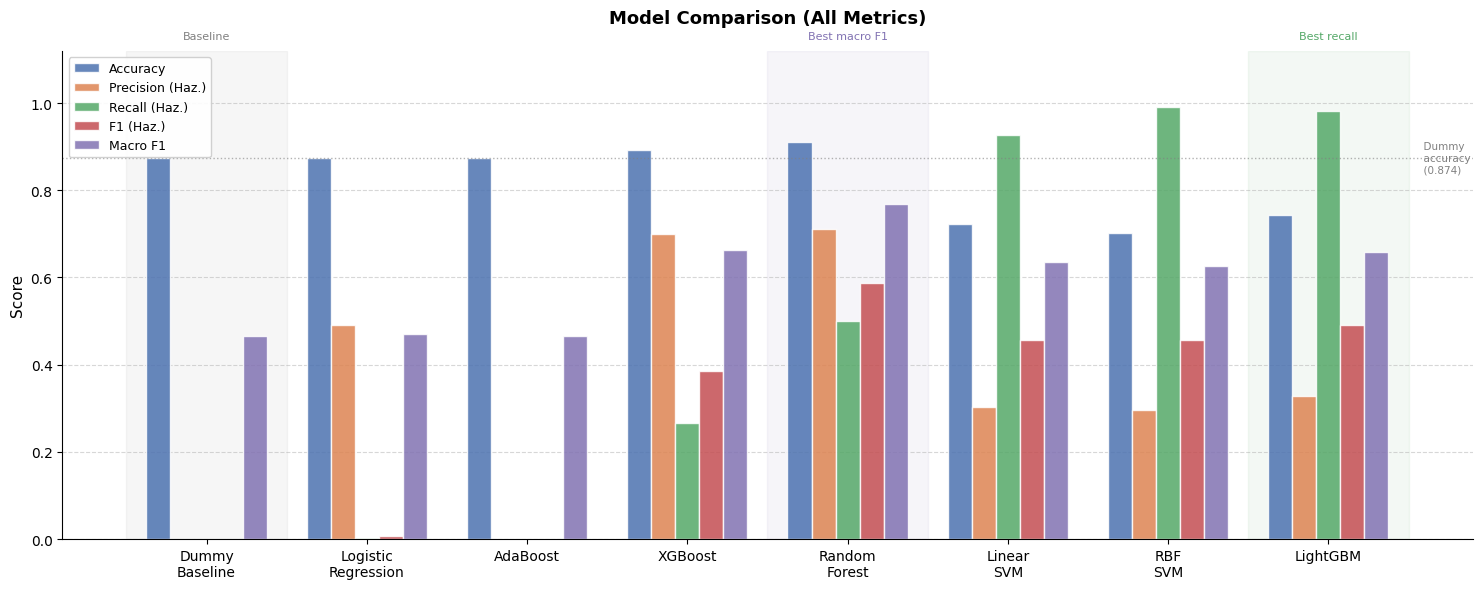

Saved: model_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Results
models = [
    'Dummy\nBaseline',
    'Logistic\nRegression',
    'AdaBoost',
    'XGBoost',
    'Random\nForest',
    'Linear\nSVM',
    'RBF\nSVM',
    'LightGBM',
]

y_preds = [
    y_pred_dummy,
    y_pred_log_reg,
    y_pred_ada,
    y_pred_xgb,
    y_pred_rf,
    y_pred_linear,
    y_pred_rbf,
    y_pred_lgb,
]

accuracy  = [accuracy_score(y_test, p)                              for p in y_preds]
precision = [precision_score(y_test, p, zero_division=0)            for p in y_preds]
recall    = [recall_score(y_test, p, zero_division=0)               for p in y_preds]
f1        = [f1_score(y_test, p, zero_division=0)                   for p in y_preds]
macro_f1  = [f1_score(y_test, p, average='macro', zero_division=0)  for p in y_preds]


x = np.arange(len(models))
width = 0.15

# Colors
c_acc      = '#4C72B0'
c_prec     = '#DD8452'
c_recall   = '#55A868'
c_f1       = '#C44E52'
c_macro    = '#8172B2'

fig, ax = plt.subplots(figsize=(15, 6))

bars1 = ax.bar(x - 2*width, accuracy,  width, label='Accuracy',           color=c_acc,    alpha=0.85, edgecolor='white')
bars2 = ax.bar(x - 1*width, precision, width, label='Precision (Haz.)',   color=c_prec,   alpha=0.85, edgecolor='white')
bars3 = ax.bar(x + 0*width, recall,    width, label='Recall (Haz.)',      color=c_recall, alpha=0.85, edgecolor='white')
bars4 = ax.bar(x + 1*width, f1,        width, label='F1 (Haz.)',          color=c_f1,     alpha=0.85, edgecolor='white')
bars5 = ax.bar(x + 2*width, macro_f1,  width, label='Macro F1',           color=c_macro,  alpha=0.85, edgecolor='white')

# Highlight the dummy baseline with a dashed boundary box
ax.axvspan(-0.5, 0.5, color='gray', alpha=0.07, zorder=0)
ax.text(0, 1.02, 'Baseline', ha='center', va='bottom',
        fontsize=8, color='gray', transform=ax.get_xaxis_transform())

# Highlight LightGBM as best model
ax.axvspan(6.5, 7.5, color='#55A868', alpha=0.07, zorder=0)
ax.text(7, 1.02, 'Best recall', ha='center', va='bottom',
        fontsize=8, color='#55A868', transform=ax.get_xaxis_transform())

# Highlight Random Forest as best balanced
ax.axvspan(3.5, 4.5, color='#8172B2', alpha=0.07, zorder=0)
ax.text(4, 1.02, 'Best macro F1', ha='center', va='bottom',
        fontsize=8, color='#8172B2', transform=ax.get_xaxis_transform())

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison (All Metrics)',
             fontsize=13, fontweight='bold', pad=20)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Reference line at dummy baseline accuracy
ax.axhline(0.874, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.text(7.55, 0.874, '  Dummy\n  accuracy\n  (0.874)',
        va='center', fontsize=7.5, color='gray')

ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

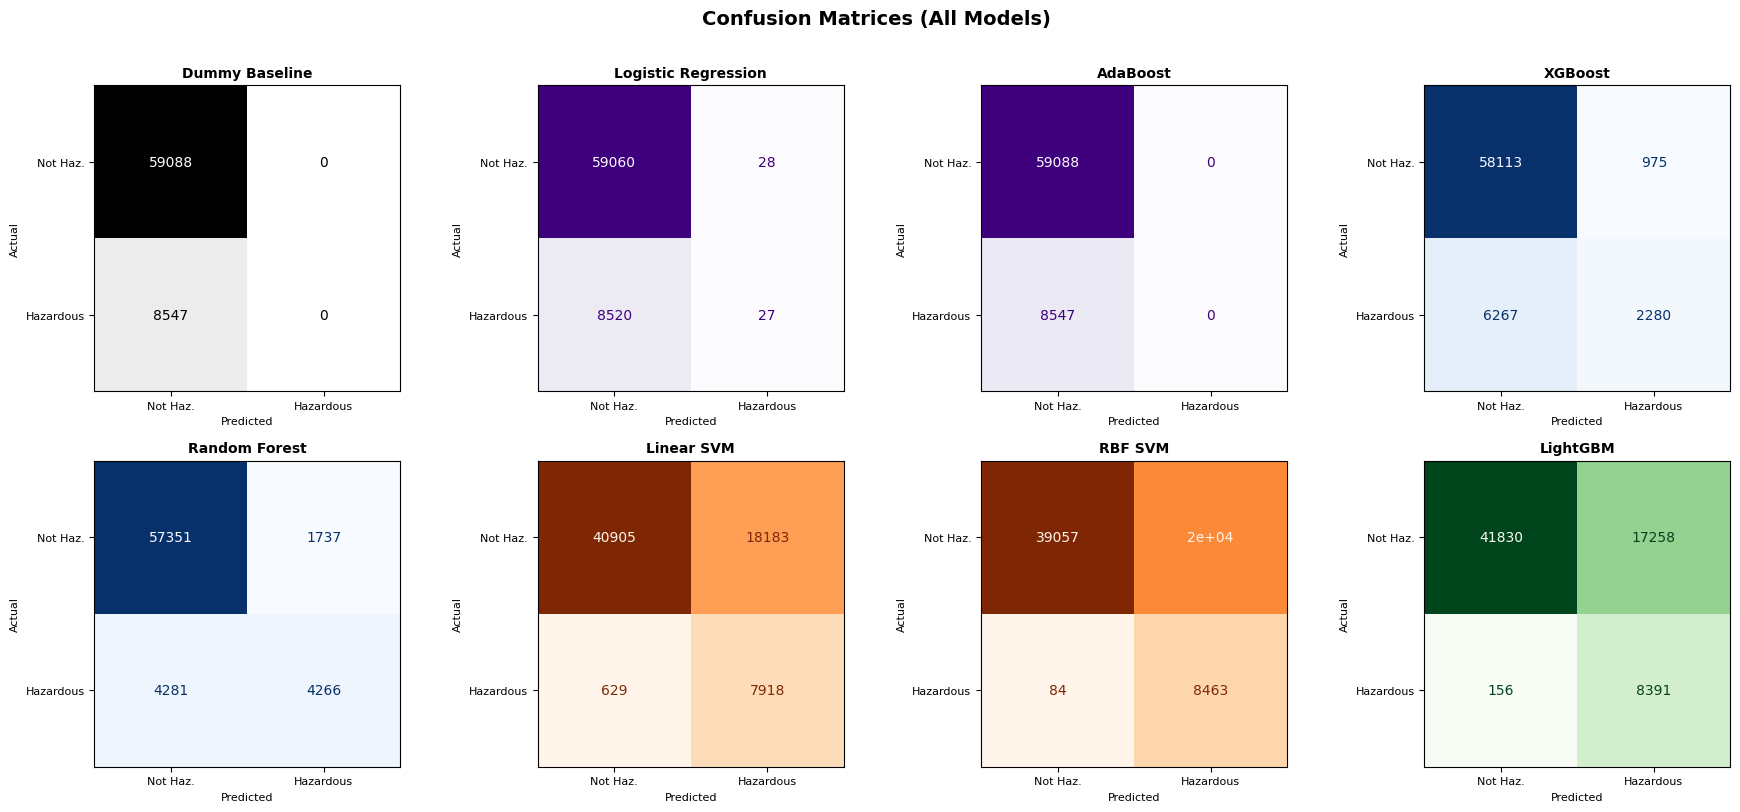

Saved: confusion_matrices_all.png


In [ ]:
# Confusion Matrices Comparison
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_names_cm = [
    'Dummy Baseline', 'Logistic Regression', 'AdaBoost', 'XGBoost',
    'Random Forest', 'Linear SVM', 'RBF SVM', 'LightGBM'
]
y_preds_cm = [
    y_pred_dummy, y_pred_log_reg, y_pred_ada, y_pred_xgb,
    y_pred_rf, y_pred_linear, y_pred_rbf, y_pred_lgb
]
cmaps = [
    'Greys', 'Purples', 'Purples', 'Blues',
    'Blues', 'Oranges', 'Oranges', 'Greens'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, name, y_pred, cmap in zip(axes, model_names_cm, y_preds_cm, cmaps):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Haz.', 'Hazardous'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle('Confusion Matrices (All Models)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_all.png")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


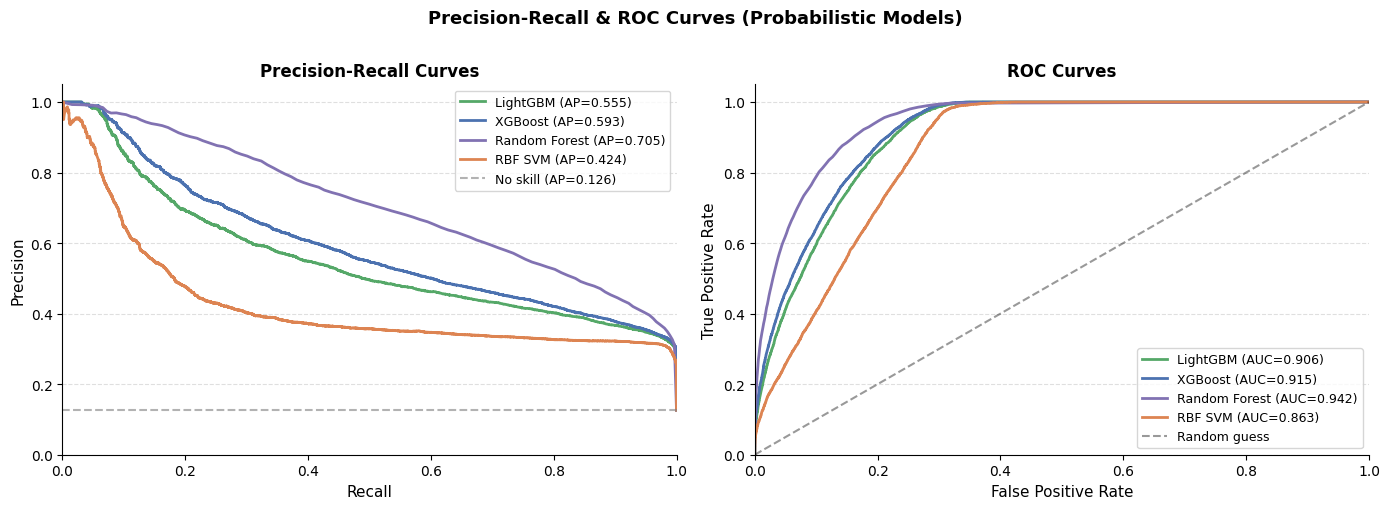

Saved: pr_roc_curves.png


In [ ]:
# precision-recall curves
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Models that support predict_proba
prob_models = [
    ('LightGBM',      lgb_model,  '#55A868'),
    ('XGBoost',       xgb,        '#4C72B0'),
    ('Random Forest', rf_model,   '#8172B2'),
    ('RBF SVM',       rbf_svm,    '#DD8452'),
]

# Explicitly close all existing figures to start fresh
plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curves
ax = axes[0]
for name, model, color in prob_models:
    # RBF SVM was trained on subsample (still predicts on full test set)
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=2)

# No-skill baseline = proportion of positive class
no_skill = y_test.sum() / len(y_test)
ax.axhline(no_skill, color='gray', linestyle='--', alpha=0.6, label=f'No skill (AP={no_skill:.3f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ROC curves
ax = axes[1]
from sklearn.metrics import roc_curve, roc_auc_score

for name, model, color in prob_models:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Precision-Recall & ROC Curves (Probabilistic Models)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pr_roc_curves.png")

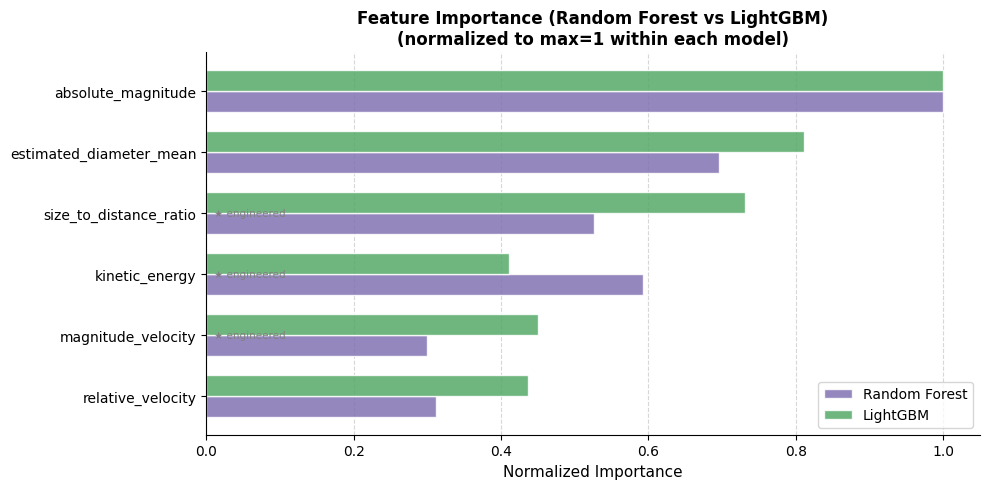

Saved: feature_importance_comparison.png


In [ ]:
# Feature Importances (Random Forest vs LightGBM)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_names = selected_features  # from your notebook

# Random Forest importances
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)

# LightGBM importances (gain = how much each split improves the model)
lgb_importances = pd.Series(lgb_model.feature_importances_, index=feature_names)

# Normalize both to 0-1 so they're comparable on the same axis
rf_norm  = rf_importances  / rf_importances.max()
lgb_norm = lgb_importances / lgb_importances.max()

# Sort by average importance
avg_importance = (rf_norm + lgb_norm) / 2
order = avg_importance.sort_values(ascending=True).index

x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.barh(x - width/2, rf_norm[order],  width, label='Random Forest', color='#8172B2', alpha=0.85, edgecolor='white')
bars2 = ax.barh(x + width/2, lgb_norm[order], width, label='LightGBM',      color='#55A868', alpha=0.85, edgecolor='white')

ax.set_yticks(x)
ax.set_yticklabels(order, fontsize=10)
ax.set_xlabel('Normalized Importance', fontsize=11)
ax.set_title('Feature Importance (Random Forest vs LightGBM)\n(normalized to max=1 within each model)',
             fontsize=12, fontweight='bold')
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10)

# Annotate engineered features
engineered = ['kinetic_energy', 'size_to_distance_ratio', 'magnitude_velocity']
for i, feat in enumerate(order):
    if feat in engineered:
        ax.annotate('★ engineered', xy=(0.01, i), fontsize=7.5,
                    color='gray', va='center')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance_comparison.png")

**Risk Score**

While our classifiers produce binary predictions (hazardous / not hazardous), a binary
label alone does not capture the full picture of an asteroid's threat level. Two asteroids
can both be classified as hazardous, yet one may be ten times larger than the other; a
distinction that matters enormously from a planetary defence perspective.

To address this, we convert LightGBM's output probabilities into a continuous risk score
that incorporates both the likelihood of hazard classification and the physical severity
of a potential impact. LightGBM was selected as the basis for the risk score because it
achieved the highest AUC-ROC (0.91) and hazardous-class recall (0.98) of all models
tested, making its probability estimates the most reliable foundation for downstream scoring.


In [ ]:
# Risk Score
from sklearn.preprocessing import MinMaxScaler

# Get LightGBM's probability of being hazardous (0 to 1)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Get the diameter for the test set rows. We need the original unscaled diameter
diameter_test = df_final_unscaled.loc[y_test.index, 'estimated_diameter_mean'].values

# Normalize diameter to 0-1 so it doesn't overpower the probability
diameter_norm = MinMaxScaler().fit_transform(diameter_test.reshape(-1, 1)).flatten()

# Combine: alpha controls how much weight goes to probability vs size
alpha = 0.6  # 60% probability, 40% severity
risk_score = (alpha * y_prob_lgb) + ((1 - alpha) * diameter_norm)

# Scale to 0-100 for readability
risk_score = risk_score * 100

# Preview top 10 most dangerous asteroids in test set
results = pd.DataFrame({
    'risk_score':        risk_score,
    'hazard_probability': y_prob_lgb,
    'diameter_mean':     diameter_test,
    'true_label':        y_test.values
}).sort_values('risk_score', ascending=False)

print("Top 10 highest risk asteroids:")
print(results.head(10).round(3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Top 10 highest risk asteroids:
       risk_score  hazard_probability  diameter_mean  true_label
22999      92.464               0.874         13.475           0
43727      77.920               0.876          8.542           0
47287      77.266               0.865          8.542           0
16996      75.094               0.829          8.542           0
24673      69.957               0.743          8.542           0
9767       69.570               0.879          5.669           1
10164      69.420               0.829          6.630           0
2795       69.394               0.876          5.669           1
55728      69.137               0.874          5.617           1
27401      68.149               0.886          5.053           1


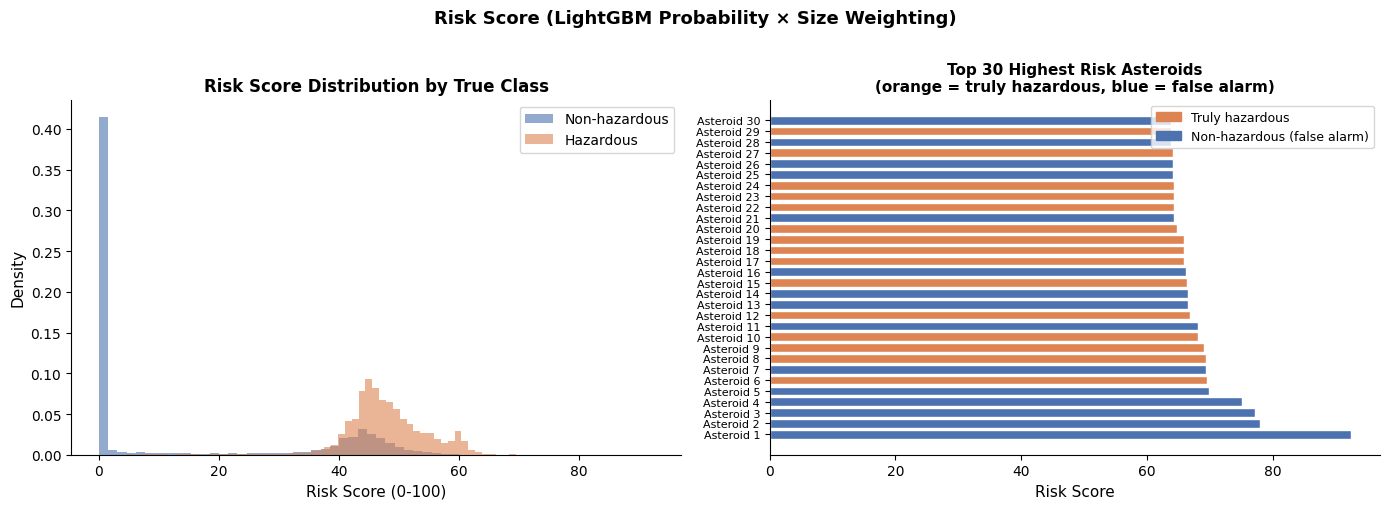

In [ ]:
# Visualize Risk Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk score distribution by true class
ax = axes[0]
ax.hist(risk_score[y_test.values == 0], bins=60, alpha=0.6,
        color='#4C72B0', label='Non-hazardous', density=True)
ax.hist(risk_score[y_test.values == 1], bins=60, alpha=0.6,
        color='#DD8452', label='Hazardous', density=True)
ax.set_xlabel('Risk Score (0-100)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Risk Score Distribution by True Class', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Top 30 highest risk
ax = axes[1]
top30 = results.head(30)
colors = top30['true_label'].map({1: '#DD8452', 0: '#4C72B0'})
ax.barh(range(len(top30)), top30['risk_score'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top30)))
ax.set_yticklabels([f'Asteroid {i+1}' for i in range(len(top30))], fontsize=8)
ax.set_xlabel('Risk Score', fontsize=11)
ax.set_title('Top 30 Highest Risk Asteroids\n(orange = truly hazardous, blue = false alarm)',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#DD8452', label='Truly hazardous'),
    Patch(color='#4C72B0', label='Non-hazardous (false alarm)')
], fontsize=9)

plt.suptitle('Risk Score (LightGBM Probability × Size Weighting)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('risk_score.png', dpi=150, bbox_inches='tight')
plt.show()